# 💬 Slack Q&A Agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/slack-qa-agent/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/slack-qa-agent/demo.ipynb)

> **People ask the same questions in #general every day.** This agent answers them from a knowledge base using RAG — and, crucially, **routes anything it isn't confident about to a human** instead of making something up.

**This notebook covers:**
1. A tiny hand-rolled **TF-IDF retriever** (RAG with zero external embedding API)
2. The **confidence gate** — the single most important part of a trustworthy Q&A bot
3. Answering real questions vs. escalating unknowns
4. A chart showing why the gate works
5. Try your own knowledge base

The whole loop runs **offline** — no API keys required to follow along.


## Step 1 — A tiny TF-IDF retriever

RAG = **Retrieve** relevant docs, then **Generate** an answer grounded in them. Production systems use vector embeddings, but the retrieval idea is clearest when you build it by hand: turn each doc and the question into TF-IDF vectors and rank by cosine similarity. No API, no vector DB — it runs anywhere.


In [1]:
from __future__ import annotations

import math
import re
from collections import Counter
from dataclasses import dataclass, field
from typing import Dict, List

_TOKEN_RE = re.compile(r"[a-z0-9]+")
_STOP = {"the","a","an","is","are","do","does","how","what","when","where","who","i","we",
         "you","to","of","for","in","on","and","or","my","can","with","it","this","that",
         "be","if","at","as","our"}


def tokenize(text: str) -> List[str]:
    return [t for t in _TOKEN_RE.findall(text.lower()) if t not in _STOP]


@dataclass
class Document:
    doc_id: str
    title: str
    text: str
    source: str = "knowledge-base"


class TfidfRetriever:
    def __init__(self, docs: List[Document]) -> None:
        self.docs = docs
        toks = [tokenize(f"{d.title} {d.text}") for d in docs]
        df: Counter = Counter()
        for t in toks:
            for term in set(t):
                df[term] += 1
        n = len(docs)
        self.idf = {t: math.log((n + 1) / (c + 1)) + 1.0 for t, c in df.items()}
        self.vecs = [self._vec(t) for t in toks]

    def _vec(self, tokens: List[str]) -> Dict[str, float]:
        tf = Counter(tokens)
        total = sum(tf.values()) or 1
        v = {t: (c / total) * self.idf.get(t, 0.0) for t, c in tf.items()}
        norm = math.sqrt(sum(x * x for x in v.values())) or 1.0
        return {t: x / norm for t, x in v.items()}

    def search(self, query: str, k: int = 3):
        q = self._vec(tokenize(query))
        scored = [(d, sum(w * vec.get(t, 0.0) for t, w in q.items()))
                  for d, vec in zip(self.docs, self.vecs)]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]


KB = [
    Document("pto", "PTO / Vacation Policy", "Vacation and paid time off: full-time employees get 20 vacation days of PTO per year, accrued monthly. Request time off in Workday at least 3 business days in advance."),
    Document("vpn", "VPN Access", "To connect to the VPN, install GlobalProtect from the IT self-service portal, sign in with your SSO credentials, and use the gateway vpn.company.com."),
    Document("expenses", "Expense Reimbursement", "To get reimbursed, submit your expense report in Expensify within 30 days of purchase. Attach receipts for anything over $25."),
    Document("wifi", "WiFi Password", "The office WiFi network is Company-Secure. Get the rotating WiFi password from the poster in each kitchen or from the #it-support channel."),
    Document("payday", "Payday / Payroll Schedule", "Payday: we get paid on the 15th and the last business day of each month. Payroll direct deposit is managed in Workday."),
    Document("laptop", "Broken Laptop / Hardware", "If your laptop broke or is damaged, file a hardware ticket in the IT self-service portal and a loaner laptop is issued within one business day."),
]
retriever = TfidfRetriever(KB)
print(f"Indexed {len(KB)} docs. Top match for 'how do I get on the vpn?':")
top_doc, top_score = retriever.search("how do I get on the vpn?", 1)[0]
print(f"  {top_doc.title}  (score {top_score:.3f})")


Indexed 6 docs. Top match for 'how do I get on the vpn?':
  VPN Access  (score 0.540)


## Step 2 — The confidence gate

A bot that always answers will confidently answer questions it has no source for — that's how you get made-up PTO policies in #general. The fix is a **gate**: if the best retrieval score is below a threshold, don't answer — escalate to a human and suggest adding a doc.


In [2]:
@dataclass
class Answer:
    question: str
    text: str
    confidence: float
    escalated: bool


def answer_question(question: str, retriever: TfidfRetriever,
                    threshold: float = 0.35, escalation_channel: str = "#people-ops") -> Answer:
    hits = retriever.search(question, k=3)
    top = hits[0][1] if hits else 0.0
    if top < threshold:
        return Answer(question, f"Not confident — routed to {escalation_channel} for a human. "
                                f"(Add a doc for this and I can answer it next time.)",
                      round(top, 3), True)
    best = hits[0][0]
    return Answer(question, f"{best.text}\n\n(Source: {best.title})", round(top, 3), False)


tests = ["How many vacation days do I get?", "How do I connect to the VPN?",
         "When is payday?", "Can I bring my dog to the office?", "What is the stock price today?"]
for q in tests:
    a = answer_question(q, retriever)
    tag = "🙋 ESCALATE" if a.escalated else "✅ ANSWER  "
    print(f"{tag} conf={a.confidence:<6} {q}")


✅ ANSWER   conf=0.504  How many vacation days do I get?
✅ ANSWER   conf=0.592  How do I connect to the VPN?
✅ ANSWER   conf=0.465  When is payday?
🙋 ESCALATE conf=0.198  Can I bring my dog to the office?
🙋 ESCALATE conf=0.0    What is the stock price today?


## Step 3 — Why the gate works: the confidence gap

Plot the top retrieval score for each question. Questions the KB **can** answer cluster high; out-of-scope questions ("dog", "stock price") fall below the threshold line and get escalated. The visible gap is what makes a fixed threshold safe.


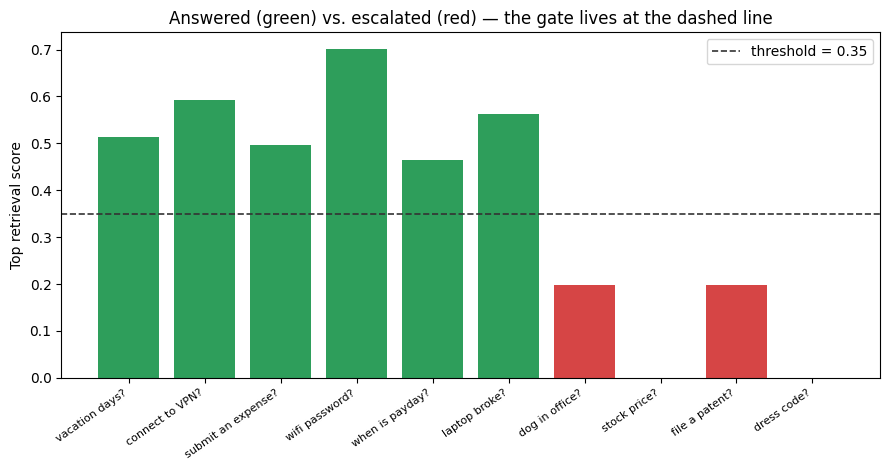

In [3]:
import matplotlib.pyplot as plt

in_kb = ["vacation days?", "connect to VPN?", "submit an expense?", "wifi password?", "when is payday?", "laptop broke?"]
out_kb = ["dog in office?", "stock price?", "file a patent?", "dress code?"]
THRESH = 0.35

qs, scores, colors = [], [], []
for q in in_kb:
    qs.append(q); scores.append(retriever.search(q, 1)[0][1]); colors.append("#2e9e5b")
for q in out_kb:
    qs.append(q); scores.append(retriever.search(q, 1)[0][1]); colors.append("#d64545")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(range(len(qs)), scores, color=colors)
ax.axhline(THRESH, color="#333", linestyle="--", linewidth=1.2, label=f"threshold = {THRESH}")
ax.set_xticks(range(len(qs)))
ax.set_xticklabels(qs, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Top retrieval score")
ax.set_title("Answered (green) vs. escalated (red) — the gate lives at the dashed line")
ax.legend()
plt.tight_layout()
plt.savefig("slack_qa_gate.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- **Retrieve:** TF-IDF cosine over a small knowledge base — no external API needed.
- **Gate:** compare the top score to a threshold. Above → answer with a citation. Below → escalate to a human.
- **Generate:** the full app optionally hands the retrieved docs to Claude to write a friendly, grounded answer (and can post it to Slack). Here we return the source doc directly so it runs offline.

The gate is the whole point: **the safest answer to an unknown question is "let me get a human,"** not a confident hallucination.


## Try your own knowledge base

Drop in your own docs and questions, then re-run. Watch how questions with no matching doc fall below the threshold and escalate.


In [4]:
# my_kb = [
#     Document("refund", "Refund Policy", "Refunds are issued within 14 days of purchase. Email billing@company.com with your order ID."),
#     Document("api_keys", "API Keys", "Generate API keys in Settings > Developer. Keys are shown once; store them securely."),
# ]
# my_retriever = TfidfRetriever(my_kb)
# for q in ["how do I get a refund?", "where do I rotate my api key?", "what is your uptime SLA?"]:
#     a = answer_question(q, my_retriever)
#     print(("ESCALATE" if a.escalated else "ANSWER"), f"(conf {a.confidence}):", q)


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 48, AI Agent Workshop.

For the interactive Streamlit version (adjustable threshold, retrieval-score inspector, Claude answers, and real Slack posting via `SLACK_BOT_TOKEN`):
```bash
pip install -r requirements.txt
streamlit run app.py
```
